# Interpretting the DRPT Anti-Integrin Model

The purpose of this notebook is for model interpretation of the DRPT Anti-Integrin. The notebook will use the fully trained model in `models_integrin_inter`

In [1]:
import argparse
import os
import random
import shutil
import time
import warnings
from enum import Enum
import pandas as pd

import argparse
import torch
import torch.nn.parallel
import torch.distributed as dist
import torch.optim
import torch.multiprocessing as mp
import torch.utils.data
import torch.utils.data.distributed

from prettytable import PrettyTable

from src.model.compound import ECFPCompoundModel, ChemBERTaCompoundModel, DrugEmbeddingCompoundModel
from src.model.model.drug_response_model import DrugResponseModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer

from src.utils.data import CompoundEncoder
from src.utils.tree import MutTreeParser
from src.utils.data.dataset import DrugResponseDataset, DrugResponseCollator, DrugResponseSampler, DrugBatchSampler, DrugDataset, CellLineBatchSampler
from src.utils.trainer import DrugResponseTrainer, DrugTrainer, DrugResponseFineTuner
import numpy as np
import torch.nn as nn
import pickle
import pubchempy as pcp
import statistics as s
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import math
from operator import itemgetter
from scipy.stats import ttest_ind

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import  StepLR
from torch.nn.utils import prune
from sklearn import metrics
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
import numpy as np
import copy
from transformers import get_linear_schedule_with_warmup
from src.utils.trainer import CCCLoss
from src.utils.data import move_to
import copy
from torch.nn import functional as F
import pickle

In [2]:
import os, sys

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

## Instantiate the Model

In [3]:
# Function to instaniate and load saved model
def instantiate_model(train_dataset, saved_model, diff_transformer=True):

    train_dataset = pd.read_csv(train_dataset, header=None, sep='\t')
    onto = "data/ontology_ctg_av.txt"
    gene2id = "data/gene2ind_ctg_av.txt"
    genotypes = {'mutation': 'data/cell2mutation_integrin.txt', 
                 'cna': 'data/cell2cnamplification_integrin.txt', 
                 'cnd': 'data/cell2cndeletion_integrin.txt'}
    hidden_dims = 128
    dropout = 0.2
    batch_size = 32
    jobs = 16
    lr = 0.0001
    wd = 0.01


    with HiddenPrints():
        compound_encoder = CompoundEncoder('Embedding', dataset=train_dataset, out="dummy/")
        compound_model = DrugEmbeddingCompoundModel(compound_encoder.num_drugs(), hidden_dims)

        tree_parser = MutTreeParser(onto, gene2id)

        device = "cuda" if torch.cuda.is_available() else "cpu"

        drug_response_model = DrugResponseModel(tree_parser, list(genotypes.keys()), hidden_dims, 
                                                compound_model, dropout=dropout, diff_transformer=diff_transformer)
    
        model = torch.load(saved_model, map_location=torch.device(device))
        model = model["state_dict"]

        drug_response_model.load_state_dict(model)
        drug_response_model.to(device)

        return(drug_response_model)

## Call a Global Forward Function that returns parameters/embeddings from the model

In [4]:
def get_model_results(train_dataset, model, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices):
    
    train_dataset = pd.read_csv(train_dataset, header=None, sep='\t')
    onto = "data/ontology_ctg_av.txt"
    gene2id = "data/gene2ind_ctg_av.txt"
    cell2id = "data/cell2ind_integrin.txt"
    genotypes = {'mutation': 'data/cell2mutation_integrin.txt', 
                 'cna': 'data/cell2cnamplification_integrin.txt', 
                 'cnd': 'data/cell2cndeletion_integrin.txt'}
    jobs = 16
    batch_size = 32

    device = "cuda" if torch.cuda.is_available() else "cpu"

    with HiddenPrints():
        compound_encoder = CompoundEncoder('Embedding', dataset=train_dataset, out="dummy/") # Keep this same as train dataset
        tree_parser = MutTreeParser(onto, gene2id)
    
        drug_response_dataset = DrugResponseDataset(train_dataset, cell2id, genotypes, compound_encoder, tree_parser, 
                                                    mut2gene=mut2gene, with_indices=with_indices)
        drug_response_collator = DrugResponseCollator(tree_parser, list(genotypes.keys()), compound_encoder, 
                                                      mut2gene=mut2gene, with_indices=with_indices)
        drug_response_dataloader = DataLoader(drug_response_dataset, shuffle=False, batch_size=batch_size,
                                              num_workers=jobs, collate_fn=drug_response_collator)
        torch.cuda.empty_cache()

        results = global_forward(model, drug_response_dataloader, device, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices)
            
        return(results)

In [5]:
def global_forward(model, dataloader, device, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices):
    
    predictions = []
    system_attention = []
    gene_attention = []
    system_embeddings = []
    gene_embeddings = []
    system_embeddings_forward = []
    results = {}

    test_df = dataloader.dataset.drug_response_df.reset_index()
    test_grouped = test_df.reset_index().groupby(1)
    nested_subtrees_forward = move_to(dataloader.dataset.tree_parser.get_nested_subtree_mask(['default'], direction='forward'), device)
    nested_subtrees_backward = move_to(dataloader.dataset.tree_parser.get_nested_subtree_mask(['default'], direction='backward'), device)
    gene2system_mask = move_to(torch.tensor(dataloader.dataset.tree_parser.gene2sys_mask, dtype=torch.bool), device)
    system2gene_mask = move_to(torch.tensor(dataloader.dataset.tree_parser.sys2gene_mask, dtype=torch.bool), device)
    
    model.to(device)
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            batch = move_to(batch, device)
            predicted, sys_attn, gene_attn, sys_embedd, gene_embedd, sys_embedd_forward = forward(model, batch['genotype'], batch['drug'],
                                                                                                  nested_subtrees_forward, nested_subtrees_backward,
                                                                                                  gene2system_mask,
                                                                                                  system2gene_mask,
                                                                                                  sys2cell=sys2cell, 
                                                                                                  cell2sys=cell2sys, 
                                                                                                  sys2gene=sys2gene,
                                                                                                  gene2drug=gene2drug,
                                                                                                  mut2gene=mut2gene, 
                                                                                                  with_indices=with_indices)
            predicted_detached = predicted.detach().cpu().numpy()
            sys_attn_detached = sys_attn.squeeze().detach().cpu().numpy()
            gene_attn_detached = gene_attn.squeeze().detach().cpu().numpy()
            sys_embedd_detached = sys_embedd.detach().cpu().numpy()
            gene_embedd_detached = gene_embedd.detach().cpu().numpy()
            sys_embedd_forward_detached = sys_embedd_forward.detach().cpu().numpy()
            
            predictions.append(predicted_detached)
            system_attention.append(sys_attn_detached)
            gene_attention.append(gene_attn_detached)
            system_embeddings.append(sys_embedd_detached)
            gene_embeddings.append(gene_embedd_detached)
            system_embeddings_forward.append(sys_embedd_forward_detached)
            
    predictions = np.concatenate(predictions)[:, 0]
    system_attention = np.concatenate(system_attention)
    gene_attention = np.concatenate(gene_attention)
    system_embeddings = np.concatenate(system_embeddings)
    gene_embeddings = np.concatenate(gene_embeddings)
    system_embeddings_forward = np.concatenate(system_embeddings_forward)
    
    for drug, indice in test_grouped.groups.items():
        results[drug] = {}
        results[drug]['celllines'] = list(test_df.loc[indice][0])
        results[drug]['actual'] = list(test_df.loc[indice][2])
        results[drug]['predictions'] = predictions[indice]
        results[drug]['system_attn'] = system_attention[indice]
        results[drug]['gene_attn'] = gene_attention[indice]
        results[drug]['system_embeddings'] = system_embeddings[indice]
        results[drug]['gene_embeddings'] = gene_embeddings[indice]
        results[drug]['system_embeddings_forward'] = system_embeddings_forward[indice]
        
    return(results)

In [6]:
def forward(model, genotype_dict, compound, nested_hierarchical_masks_forward, nested_hierarchical_masks_backward,
                gene2sys_mask, sys2gene_mask, comp2sys_masks=None, sys2cell=True, cell2sys=True, sys2gene=False, 
                gene2drug=False, mut2gene=True, with_indices=True):
        
        batch_size = compound.size(0)
        if mut2gene:
            gene_embedding = model.get_mut2gene(genotype_dict, with_indices=with_indices, batch_size=batch_size)
            system_embedding = model.system_embedding.weight.unsqueeze(0).expand(batch_size, -1, -1)[:, :-1, :]
            system_embedding, gene_effect = model.get_gene2sys(system_embedding, gene_embedding, gene2sys_mask)
            system_embedding = system_embedding + model.effect_norm(gene_effect)
        else:
            system_embedding = model.get_mut2system(genotype_dict, with_indices=with_indices, batch_size=batch_size)
            gene_embedding = model.gene_embedding.weight.unsqueeze(0).expand(batch_size, -1, -1)[:, :-1, :]
        
        if sys2cell:
            system_embedding = model.get_sys2sys(system_embedding, nested_hierarchical_masks_forward, direction='forward', 
                                                return_updates=False, with_indices=False)
            system_embedding_forward = system_embedding.clone()
        if cell2sys:
            system_embedding = model.get_sys2sys(system_embedding, nested_hierarchical_masks_backward, direction='backward', 
                                                return_updates=False, with_indices=False)
        if sys2gene:
            gene_embedding, system_effect_on_gene = model.get_sys2gene(gene_embedding, system_embedding, sys2gene_mask)
            gene_embedding = gene_embedding + model.effect_norm(system_effect_on_gene)
        
        compound_embedding = model.get_compound_embedding(compound, unsqueeze=True)
        
        if gene2drug:
            prediction = model.prediction(model.predictor_genes_systems, compound_embedding, system_embedding, gene_embedding)
        else:
            prediction = model.prediction(model.predictor_systems, compound_embedding, system_embedding)
        
        drug_system_embedding, system_attention = model.get_system2comp(compound_embedding, system_embedding, attention=True, score=False)
        drug_gene_embedding, gene_attention = model.get_gene2comp(compound_embedding, gene_embedding, attention=True, score=False)

        return(prediction, system_attention, gene_attention, system_embedding, gene_embedding, system_embedding_forward)

## Get the predictions, system attention values per drug, and system embeddings

In [7]:
loaded = torch.load('models_integrin_interp/integrin_model.pt', map_location=torch.device('cpu'))
print(loaded['arguments'])

Namespace(batch_size=32, bert=None, cell2id='data/cell2ind_integrin.txt', cell2sys=True, compound_epochs=10, compound_layers=[256], cuda=0, diff_transformer=True, dist_backend='nccl', dist_url='tcp://224.66.41.62:23456', distributed=False, dropout=0.2, drug_embedding=True, epochs=500, gene2drug=False, gene2id='data/gene2ind_ctg_av.txt', gene_embedding=None, genotypes={'mutation': 'data/cell2mutation_integrin.txt', 'cna': 'data/cell2cnamplification_integrin.txt', 'cnd': 'data/cell2cndeletion_integrin.txt'}, gpu=0, hidden_dims=128, jobs=16, l2_lambda=0.01, local_rank=1, lr=0.0001, model=None, multiprocessing_distributed=False, mut2gene=True, n_bits=512, onto='data/ontology_ctg_av.txt', out='models_integrin_interp/integrin_model.pt', radius=2, rank=-1, seed=None, subtree_order=['default'], sys2cell=True, sys2gene=False, system_embedding=None, test='data/full_model/integrin_response.txt', train='data/full_model/integrin_response.txt', val='data/full_model/integrin_response.txt', val_step=1

In [8]:
train = 'data/full_model/integrin_response.txt'
model_integrin = 'models_integrin_interp/integrin_model.pt'
model = instantiate_model(train, model_integrin, diff_transformer=True)
results = get_model_results(train, model, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, mut2gene=True, with_indices=True)

### Save results

In [9]:
with open("results_integrin.pkl", "wb") as handle:
    pickle.dump(results, handle)

### Load in previous results

In [7]:
with open("results_integrin.pkl", "rb") as handle:
    results = pickle.load(handle)

## Get the hiearchy and system/gene to indexes

In [8]:
with open("mappings/nest_to_old_name.pkl", "rb") as handle:
    nest_to_name = pickle.load(handle)

onto = "data/ontology_ctg_av.txt"
gene2id = "data/gene2ind_ctg_av.txt"

with HiddenPrints():
    tree_parser = MutTreeParser(onto, gene2id)
    system_mapping = {i: tree_parser.ind2sys[i] for i in range(len(tree_parser.ind2sys))}
    gene_mapping = {i: tree_parser.ind2gene[i] for i in range(len(tree_parser.ind2gene))}

## Load in system_to_genes mapping

In [9]:
with open("mappings/system_to_genes.pkl", "rb") as handle:
    system_genes = pickle.load(handle)

## Create value for system size

In [10]:
import math
system_sizes = {}
for system in system_genes.keys():
    system_sizes[system] = math.log(len(system_genes[system]))

In [11]:
len(system_sizes)

131

## Evaluate Importance of System per Drug

In [12]:
importance = {}
drugs = ['Cilengitide', 'Cpd_2']
for drug in drugs:
    predictions = results[drug]['predictions']
    importance[drug] = {}
    for i in range(131):
        system_attn_i = results[drug]['system_attn'][:,i]
        system = system_mapping[i] 
        importance[drug][system] = abs(pearsonr(predictions, system_attn_i)[0])

## Visualizations for Interpretability

### What is the Distributions of Important Systems for DRPT Integrin?

In [13]:
def define_box_properties(plot_name, color_code):
    for k, v in plot_name.items():
        plt.setp(plot_name.get(k), color=color_code)
        
    plt.plot([], c=color_code)

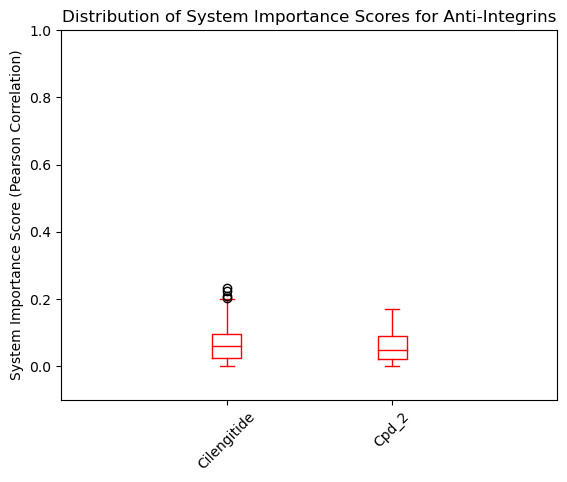

In [14]:
drugs = drugs = ['Cilengitide', 'Cpd_2']
systems = list(nest_to_name.keys())
drpt = []
for drug in drugs:
    drpt_drug = []
    for system in systems:
        drpt_drug.append(importance[drug][system])
    drpt.append(drpt_drug)

drpt_plot = plt.boxplot(drpt, positions=np.array(
    np.arange(len(drpt)))*2.0, widths=0.35)

define_box_properties(drpt_plot, "red")

plt.rcParams["figure.figsize"] = [5, 5]
plt.xticks(np.arange(0, len(drugs) * 2, 2), drugs, fontsize = 10)
plt.xlim(-2, len(drugs)*2)
plt.ylim(-0.1, 1)
plt.yticks(fontsize = 10)
plt.ylabel("System Importance Score (Pearson Correlation)", fontsize = 10)
plt.xticks(rotation=45, fontsize = 10)
plt.title('Distribution of System Importance Scores for Anti-Integrins', fontsize = 12)
plt.show()

## Top 30 Most Important Systems

In [17]:
import seaborn as sns

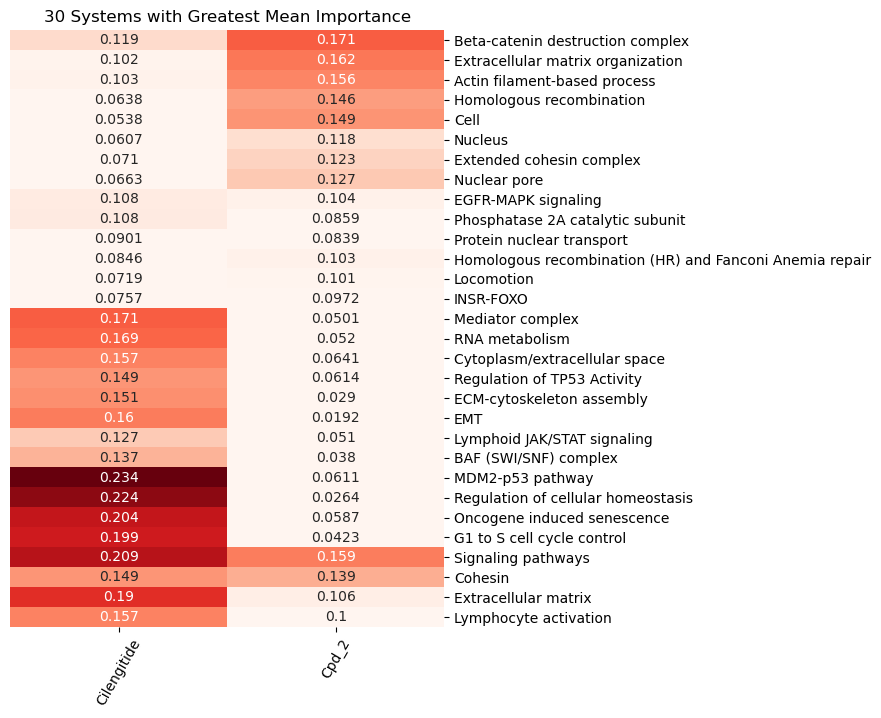

In [18]:
systems = list(importance[drugs[0]].keys())
scores = np.zeros((len(systems), len(drugs)))
sys_name = []
for i in range(len(systems)):
    for j in range(len(drugs)):
        scores[i][j] = importance[drugs[j]][systems[i]]
    sys_name.append(nest_to_name[systems[i]])

scores = pd.DataFrame(scores, index=sys_name, columns=drugs)
row_means = scores.mean(axis=1)
top_30_rows = row_means.nlargest(30).index
df_top_30 = scores.loc[top_30_rows]

g = sns.clustermap(df_top_30, vmin = 0.1, annot=True, fmt = '.3g', figsize = (10,8), 
                   annot_kws={"size": 10}, cbar_pos = None,
                  row_cluster=True, col_cluster=True, cmap = "Reds")
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 10, rotation = 60)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 10)
g.ax_heatmap.set_title("30 Systems with Greatest Mean Importance", fontsize = 12)
plt.show()

## Evaluate Importance with the Null Model

In [15]:
from scipy.stats import norm
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

### Load in Null Model Results

In [16]:
with open('null_importance_integrin.pkl', 'rb') as handle:
    null_importance = pickle.load(handle)

In [17]:
null_importance

{'Cilengitide': {'Mean': -0.003174812325292692, 'Std': 0.0353204521640337},
 'Cpd_2': {'Mean': 0.0002870999455813793, 'Std': 0.039142552481858266}}

### Function for computing Z-test

In [18]:
def importance_z_test_2(null, drug, x):

    null_mean = null[drug]["Mean"]
    null_std = null[drug]["Std"]

    z_score = (x - null_mean) / null_std
    p_value = 2 * (1 - norm.cdf(abs(z_score)))

    return p_value

### Compute Importance P-Value for each System for Each Drug

In [20]:
from statsmodels.stats.multitest import fdrcorrection
import copy

In [21]:
def fdr_correct_nested_dict(pval_dict):
    corrected_dict = copy.deepcopy(pval_dict)

    for drug, system_pvals in pval_dict.items():
        systems = list(system_pvals.keys())
        pvals = list(system_pvals.values())

        # Perform FDR correction
        _, fdr_corrected = fdrcorrection(pvals)

        # Update the dictionary
        for sys, corrected_p in zip(systems, fdr_corrected):
            corrected_dict[drug][sys] = corrected_p

    return corrected_dict

drugs = ['Cilengitide', 'Cpd_2']

imp_pvalues = {}
for drug in drugs:
    imp_pvalues[drug] = {}
    predictions = results[drug]['predictions']
    for i in range(131):
        system = nest_to_name[system_mapping[i]]
        drug_attn = results[drug]['system_attn']
        system_attn = drug_attn[:, i]
        pearson = pearsonr(system_attn, predictions)[0]
        imp_p_value = importance_z_test_2(null_importance, drug, pearson) * 131
        imp_pvalues[drug][system] = imp_p_value

### Save the Importance P-Values

In [22]:
with open("integrin_importance_pvalues.pkl", "wb") as handle:
    pickle.dump(imp_pvalues, handle)

### Which Systems are Significantly Important?

In [62]:
g2pt_significant = {}
significant_systems = set()
for drug in drugs:
    g2pt_significant[drug] = set()
    for nest in nest_to_name.keys():
        system = nest_to_name[nest]
        if len(system_genes[system]) > 400:
            continue
        g2pt_imp = imp_pvalues[drug][system]
        if g2pt_imp < 0.05:
            g2pt_significant[drug].add(system)
            significant_systems.add(system)

### Number of Important Systems

In [63]:
for drug in drugs:
    print(drug, len(g2pt_significant[drug]))

Cilengitide 21
Cpd_2 7


In [66]:
significant_systems

{'Actin filament-based process',
 'BAF (SWI/SNF) complex',
 'Beta-catenin destruction complex',
 'Cellular response to DNA damage',
 'Chromosome centrometric region',
 'Cohesin',
 'Cytoplasm/extracellular space',
 'ECM-cytoskeleton assembly',
 'EMT',
 'Extracellular matrix',
 'Extracellular matrix organization',
 'G1 to S cell cycle control',
 'H3 acetylation and H3K4 methylation crosstalk',
 'Homologous recombination',
 'Lymphocyte activation',
 'MDM2-p53 pathway',
 'MHC class I including non-classical MHCs',
 'Mediator complex',
 'Oncogene induced senescence',
 'RBL-TP53 complex',
 'RNA metabolism',
 'Regulation of TP53 Activity',
 'Regulation of cellular homeostasis',
 'Signaling pathways',
 'mTOR regulation of mRNA translation',
 'p53 regulation of cell cycle'}

### Save the Important Integrin Systems

In [67]:
with open("important_systems_integrin.pkl", "wb") as handle:
    pickle.dump(significant_systems, handle)

## Create New NeST VNN File for Viewing in Cytoscape

In [86]:
nest_vnn = pd.read_csv("mappings/NeST-G2PT.csv")
nest_vnn.head()

,All_Genes,Annotation,C_rho_mean_cell,C_rho_mean_genie,cellvsgenie,cellvsgenie_ratio,Direct_Genes,Importance,name,NEST ID,...,P_rho_genie_bins,P_rho_mean_cell,P_rho_mean_genie,RLIPP_cell,RLIPP_genie,selected,shared name,Size-Log,Size_All,Size_Direct
0,"BCLAF1,BRD4,CASP8,CDC73,CREBBP,DDX3X,EWSR1,FUB...",mRNA splicing,0.3750,0.3320,cells ~ clinical,0.898113,"BRD4,DDX3X,FUBP1,GATA3,PRCC,PRKDC",0,mRNA splicing,NEST:19,...,1,0.3710,0.3332,0.9884,1.0034,False,mRNA splicing,1.342423,22,6.0
1,"BARD1,BLM,BRCA1,BRCA2,BUB1B,CCND1,CCND2,CCND3,...",Regulation of CDK activity I,0.6988,0.6434,cells ~ clinical,0.900143,"CDK5,CDKN1C,MSH2,MSH6,TERT",1,Regulation of CDK activity,NEST:50,...,4,0.6970,0.6274,0.9968,0.9740,False,Regulation of CDK activity,1.612784,41,5.0
2,"AURKA,AURKB,BARD1,BLM,BRCA1,BRCA2,BRIP1,BUB1B,...",DNA metabolic process,0.5714,0.5040,cells ~ clinical,0.795732,"CCNE1,CDKN1A,CDKN1B,CKS1B,MLH3,POLD1,POLE,RB1,...",1,DNA metabolic process,NEST:30,...,3,0.6560,0.5220,1.1536,1.0374,False,DNA metabolic process,1.505150,32,10.0
3,"CTNNB1,EP300,EZH2,HIST3H3,TP53",H3-ac. & H3K4-me crosstalk,0.2676,0.2940,cells ~ clinical,1.379712,"CTNNB1,EP300,EZH2,HIST3H3,TP53",1,H3 acetylation and H3K4 methylation crosstalk,NEST:155,...,2,0.2918,0.4026,18.6706,0.2196,False,H3 acetylation and H3K4 methylation crosstalk,0.698970,5,5.0
4,"RAD21,SMARCA4,SMC1A,SMC3,STAG1,STAG2",Extended cohesin complex,0.3496,0.2032,cell,0.581354,SMARCA4,0,Extended cohesin complex,NEST:121,...,0,0.3368,0.1958,0.9546,0.9598,False,Extended cohesin complex,0.778151,6,1.0


In [87]:
len(nest_vnn)

131

In [88]:
significant = []
pvalues = {}
for ind in nest_vnn.index:
    nest = nest_vnn["NEST ID"][ind]
    system_name = nest_to_name[nest]
    nest_vnn.at[ind, 'Annotation'] = system_name
    
    if system_name in significant_systems:
        significant.append(1)
    else:
        significant.append(0)
    
    for drug in drugs:
        pval = -1*math.log10(imp_pvalues[drug][system_name])
        if pval < 0:
            pval = 0
        if pvalues.get(system_name):
            if pvalues[system_name] < pval:
                pvalues[system_name] = pval
        else:
            pvalues[system_name] = pval
            
nest_vnn["Importance"] = significant

nest_pvalues = pd.DataFrame({"Annotation": list(pvalues.keys()), "P-Values": list(pvalues.values())})
nest_vnn = pd.merge(nest_vnn, nest_pvalues, on = "Annotation")

In [89]:
nest_vnn.to_csv("mappings/integrin_important.csv", index = False, encoding = 'utf-8')

## Inspect the Performance at Each Epoch for the Fully Trained Model 

In [23]:
with open("models_integrin_interp/val_performance.pkl", "rb") as handle:
    val = pickle.load(handle)

In [25]:
def plot_pearson_per_drug(metrics):
    # Sort epochs
    epochs = sorted(metrics.keys())
    
    # Extract all drugs
    all_drugs = set()
    for v in metrics.values():
        all_drugs.update(v['pearson_per_drug'].keys())
    all_drugs = sorted(all_drugs)

    # Collect values per drug
    drug_to_values = {drug: [] for drug in all_drugs}
    for epoch in epochs:
        for drug in all_drugs:
            drug_to_values[drug].append(metrics[epoch]['pearson_per_drug'].get(drug, None))

    # Plot
    plt.figure(figsize=(10, 6))
    for drug, values in drug_to_values.items():
        plt.plot(epochs, values, marker='o', label=drug)

    plt.xlabel('Epoch')
    plt.ylabel('Pearson Correlation')
    plt.title('Pearson Correlation per Drug Across Epochs')
    plt.legend(title='Drug')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

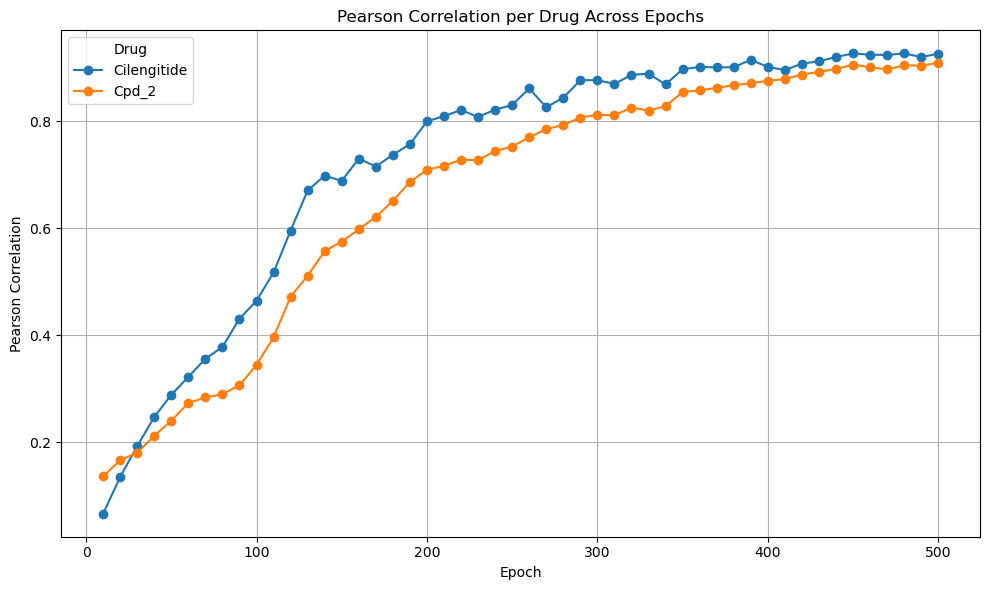

In [26]:
plot_pearson_per_drug(val)